In [21]:
import os
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Subset
from torchvision import datasets, transforms, models
from torchvision.models import ResNet18_Weights

from sklearn.metrics import classification_report

In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

Using device: cuda
GPU name: Tesla P100-PCIE-16GB


In [23]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

In [24]:
dataset_path = Path("/kaggle/input/datasets/emmarex/plantdisease/PlantVillage")

print("Dataset exists:", dataset_path.exists())
print("Dataset path:", dataset_path)

Dataset exists: True
Dataset path: /kaggle/input/datasets/emmarex/plantdisease/PlantVillage


In [25]:
full_dataset = datasets.ImageFolder(root=dataset_path)

print("Total images:", len(full_dataset))
print("Number of classes:", len(full_dataset.classes))
print("First 10 classes:", full_dataset.classes[:10])

Total images: 20638
Number of classes: 15
First 10 classes: ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot']


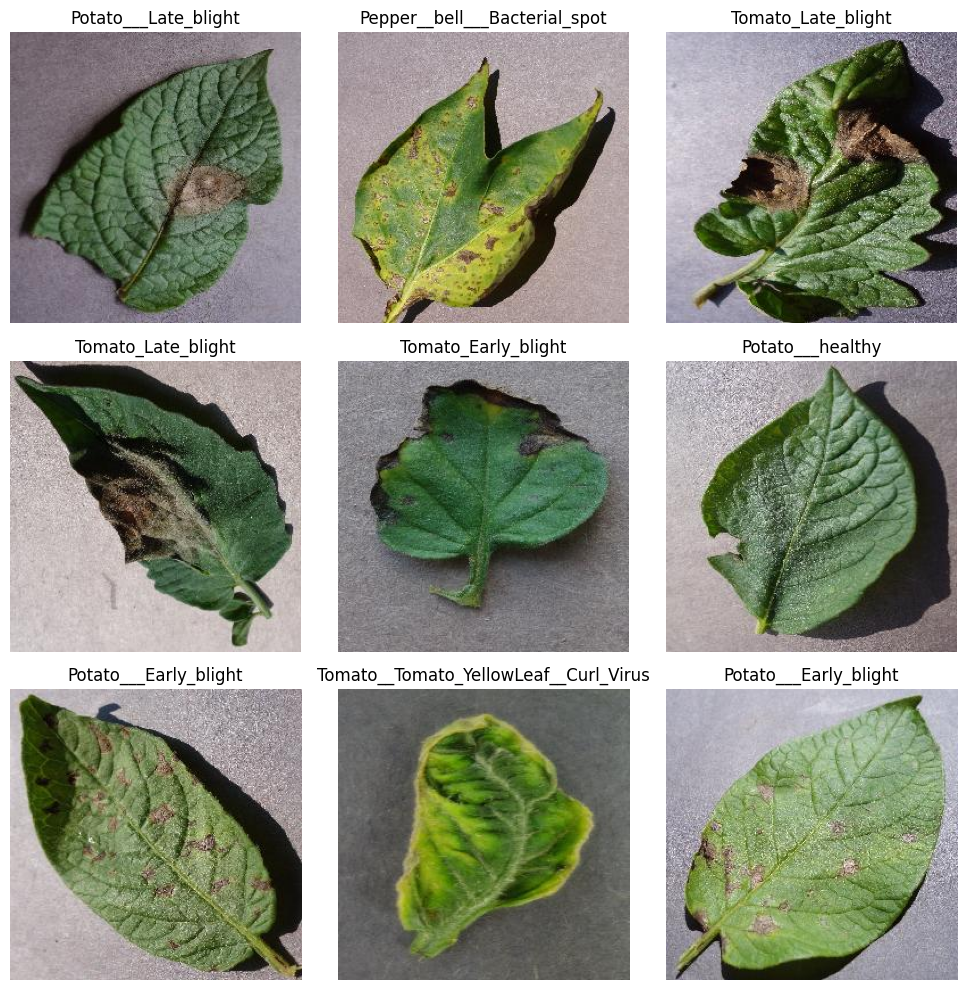

In [26]:
def show_samples(dataset, n=9):
    plt.figure(figsize=(10, 10))
    indices = random.sample(range(len(dataset)), n)

    for i, idx in enumerate(indices):
        image, label = dataset[idx]
        plt.subplot(3, 3, i + 1)
        plt.imshow(image)
        plt.title(dataset.classes[label])
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_samples(full_dataset, 9)

In [27]:
image_size = 224
batch_size = 32

train_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [28]:
train_dataset_full = datasets.ImageFolder(root=dataset_path, transform=train_transform)
val_dataset_full = datasets.ImageFolder(root=dataset_path, transform=val_transform)

class_names = train_dataset_full.classes
num_classes = len(class_names)

print("Classes:", num_classes)

Classes: 15


In [29]:
dataset_size = len(train_dataset_full)

train_size = int(0.7 * dataset_size)
val_size = int(0.15 * dataset_size)
test_size = dataset_size - train_size - val_size

train_subset_raw, val_subset_raw, test_subset_raw = random_split(
    train_dataset_full,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

train_indices = train_subset_raw.indices
val_indices = val_subset_raw.indices
test_indices = test_subset_raw.indices

train_subset = Subset(train_dataset_full, train_indices)
val_subset = Subset(val_dataset_full, val_indices)
test_subset = Subset(val_dataset_full, test_indices)

print("Train size:", len(train_subset))
print("Validation size:", len(val_subset))
print("Test size:", len(test_subset))

Train size: 14446
Validation size: 3095
Test size: 3097


In [30]:
train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_subset, batch_size=batch_size, shuffle=False, num_workers=2)

In [31]:
weights = ResNet18_Weights.DEFAULT
model = models.resnet18(weights=weights)

for param in model.parameters():
    param.requires_grad = False

model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

print(model)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 173MB/s] 


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [32]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

In [33]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    running_correct = 0
    total = 0

    for inputs, labels in dataloader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        _, preds = torch.max(outputs, 1)

        running_loss += loss.item() * inputs.size(0)
        running_correct += torch.sum(preds == labels).item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_correct / total
    return epoch_loss, epoch_acc

In [34]:
def evaluate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    running_correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            _, preds = torch.max(outputs, 1)

            running_loss += loss.item() * inputs.size(0)
            running_correct += torch.sum(preds == labels).item()
            total += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / total
    epoch_acc = running_correct / total
    return epoch_loss, epoch_acc, all_labels, all_preds

In [35]:
num_epochs = 5

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

start_time = time.time()

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")
    print("-" * 50)

elapsed_time = time.time() - start_time
print(f"Training completed in {elapsed_time/60:.2f} minutes")

Epoch [1/5]
Train Loss: 0.9451 | Train Acc: 0.7520
Val   Loss: 0.4880 | Val   Acc: 0.8656
--------------------------------------------------
Epoch [2/5]
Train Loss: 0.4509 | Train Acc: 0.8737
Val   Loss: 0.3524 | Val   Acc: 0.8979
--------------------------------------------------
Epoch [3/5]
Train Loss: 0.3641 | Train Acc: 0.8897
Val   Loss: 0.3204 | Val   Acc: 0.8973
--------------------------------------------------
Epoch [4/5]
Train Loss: 0.3202 | Train Acc: 0.9028
Val   Loss: 0.2997 | Val   Acc: 0.9076
--------------------------------------------------
Epoch [5/5]
Train Loss: 0.3015 | Train Acc: 0.9075
Val   Loss: 0.2702 | Val   Acc: 0.9157
--------------------------------------------------
Training completed in 3.85 minutes


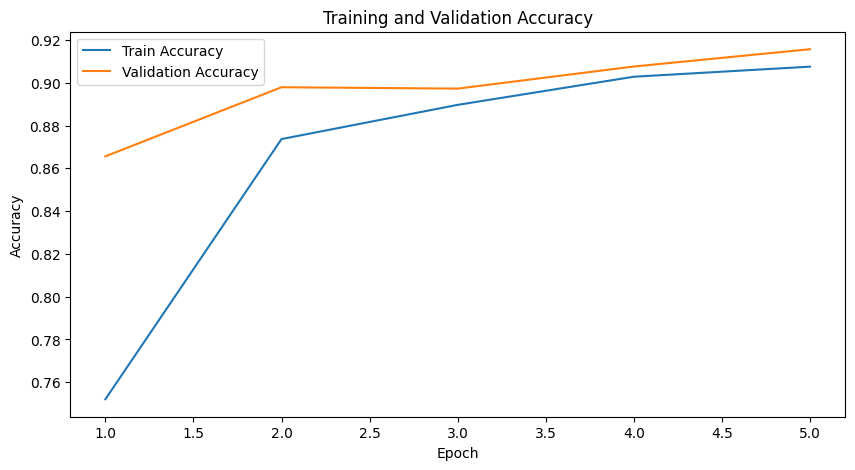

In [36]:
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs, history["train_acc"], label="Train Accuracy")
plt.plot(epochs, history["val_acc"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.show()

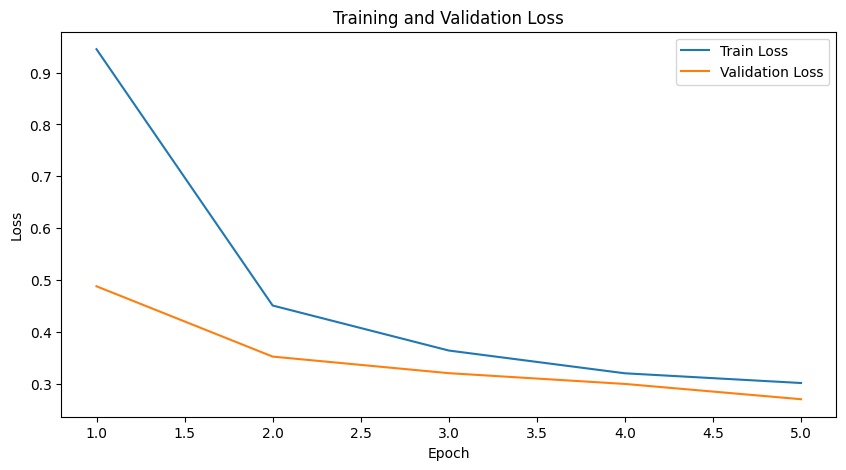

In [37]:
plt.figure(figsize=(10, 5))
plt.plot(epochs, history["train_loss"], label="Train Loss")
plt.plot(epochs, history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

In [38]:
test_loss, test_acc, y_true, y_pred = evaluate(model, test_loader, criterion, device)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Test Loss: 0.2559
Test Accuracy: 0.9186


In [39]:
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.93      0.96      0.94       140
                     Pepper__bell___healthy       0.97      1.00      0.98       241
                      Potato___Early_blight       0.98      0.96      0.97       156
                       Potato___Late_blight       0.94      0.94      0.94       168
                           Potato___healthy       0.95      0.95      0.95        22
                      Tomato_Bacterial_spot       0.93      0.96      0.95       335
                        Tomato_Early_blight       0.74      0.72      0.73       150
                         Tomato_Late_blight       0.91      0.90      0.91       274
                           Tomato_Leaf_Mold       0.92      0.86      0.88       139
                  Tomato_Septoria_leaf_spot       0.89      0.90      0.89       264
Tomato_Spider_mites_Two_spotted_spider_mite       0.83      0.94

In [40]:
torch.save(model.state_dict(), "plant_disease_resnet18.pth")
print("Model saved as plant_disease_resnet18.pth")

Model saved as plant_disease_resnet18.pth
